# Matthew Pollard and Patrick Dela Rosa 
# Milestone 1

Our contributions for each part of the assignment are denoted by our initials.

# Part 1 - Application Area (Winter Weather Hazards) (MP and PD)
- We are thinking of focusing on winter weather hazards and specific conditions that can cause or enhance these conditions
- It is interesting to explore due to different risks associated with these weather conditions. It is also interesting to closely monitor these storms out of personal interests. 
- It is useful to quantify this due to effects on travel conditions, school closures, power grids, energy usage, etc.
### Past Weather Event
- Late January Snow Storm of 2026
- We want to explore this kind of index because large snow, sleet, and particularly ice accumulations, coupled with gusty winds can lead to significant disruptions to daily life with heavily decreased visibilities and a high number of power outages over a large area, especially during the 1/25-26/2026 winter storm which covered most of the eastern US and delivered a wide swath of 12+ inch snow totals and high sleet and ice accretion.

  
### Different parameters
- Temperature, snow depth, wind speed, precipitation type (freezing rain, sleet, snow, ice), visibility, wind chill, 10m wind gust

### Who Will Use
- Anyone in the general public, especially emergency management operators, can use this index because this index will highlight residential and transportation impacts.
- School districts and universities for school closure decisions

### Hazard Index (preliminary)
- 0: No hazard
- 1: Little to no impact
- 2: Slight impacts
- 3: Moderate impacts
- 4: Major impacts
- 5: Extreme impacts

### Weighting of Variables (preliminary)
- Precipitation type, precipitation rate, wind chill, ice accumulation, snow depth, and 10m wind gust will all be important variables to be weighted heavily in our index

# Part 2 - Relevant Model Data and Surface Observations
Data taken from Jan 23 to Jan 27 2026

In [2]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask

## Testing Data

In [29]:
run = pd.Timestamp("2026-01-23-00")

In [30]:
# model run Jan 23 2026
#H = Herbie(run, model="ifs", product="oper", fxx=6, save_dir='./courses/meteo473/sp26/group6/data/', overwrite=True)

In [31]:
#H.inventory()

In [32]:
# specific parameters: geopotential height, 2m temp, snow depth (m), wind chill, wind speed, u and v components, visibility, total precipitation
#
ss = r":(gh|t|u|v|2t|sd|10fg|sp|ws|tp|ptype|tprate):" 

In [33]:
#H.inventory().param.unique()

In [34]:
#H.inventory(ss)

In [35]:
#fp = H.download(ss)

In [36]:
#ds = xr.open_dataset(fp)
#ds

## Saving Data (MP)

In [112]:
# Saving data and variables into a NetCDF file

In [3]:
run = pd.Timestamp("2026-01-23-00")
H = FastHerbie([run], model="ifs", product="oper", fxx=np.arange(0,102,6).tolist(), save_dir='./data/', overwrite=True)

In [11]:
#Note (from Luke) - we had to load 2m temperature separately because the 'height above ground' coordinate was giving issues. 
ss1 = r":(2t):"
ss2 = r":(gh|t|u|v|sd|10fg|sp|ws|tp|ptype|tprate):" 
H.inventory(ss2)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

,grib_message,start_byte,end_byte,range,reference_time,valid_time,step,param,levelist,levtype,number,domain,expver,class,type,stream,search_this,FILE
0,8,3841534,4871060,3841534-4871060,2026-01-23,2026-01-23,0 days,ptype,NaN,sfc,NaN,g,0001,od,fc,oper,:ptype:sfc:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
1,11,5703885,6384783,5703885-6384783,2026-01-23,2026-01-23,0 days,tprate,NaN,sfc,NaN,g,0001,od,fc,oper,:tprate:sfc:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
2,17,8320627,8749643,8320627-8749643,2026-01-23,2026-01-23,0 days,gh,100,pl,NaN,g,0001,od,fc,oper,:gh:100:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
3,19,8749867,9485485,8749867-9485485,2026-01-23,2026-01-23,0 days,v,500,pl,NaN,g,0001,od,fc,oper,:v:500:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
4,24,13202368,13913549,13202368-13913549,2026-01-23,2026-01-23,0 days,u,500,pl,NaN,g,0001,od,fc,oper,:u:500:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,154,122150785,122584169,122150785-122584169,2026-01-23,2026-01-27,4 days,gh,150,pl,NaN,g,0001,od,fc,oper,:gh:150:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
981,155,122584169,123123438,122584169-123123438,2026-01-23,2026-01-27,4 days,sp,NaN,sfc,NaN,g,0001,od,fc,oper,:sp:sfc:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
982,156,123123438,123817050,123123438-123817050,2026-01-23,2026-01-27,4 days,u,700,pl,NaN,g,0001,od,fc,oper,:u:700:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...
983,158,125163568,125877302,125163568-125877302,2026-01-23,2026-01-27,4 days,v,700,pl,NaN,g,0001,od,fc,oper,:v:700:pl:g:0001:od:fc:oper,https://storage.googleapis.com/ecmwf-open-data...


In [12]:
filepath1 = H.download(ss1)
filepath2 = H.download(ss2)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [116]:
filepath1

[PosixPath('data/ifs/20260123/subset_a9ef0171__20260123000000-0h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9895c75__20260123000000-18h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9b297da__20260123000000-6h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a91c2f9a__20260123000000-48h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9782664__20260123000000-54h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9122664__20260123000000-12h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9072664__20260123000000-96h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a90ec02c__20260123000000-36h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9432f9a__20260123000000-60h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a90e2f9a__20260123000000-24h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9e748ac__20260123000000-42h-oper-fc.grib2'),
 PosixPath('data/ifs/20260123/subset_a9267441__20260123000000-90h-oper-fc.grib2'),
 Posix

In [13]:
ds1 = xr.open_mfdataset(filepath1, combine='nested', concat_dim='valid_time')
ds2 = xr.open_mfdataset(filepath2, combine='nested', concat_dim='valid_time', coords = 'minimal', compat = 'override')

Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a9b297da__20260123000000-6h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a9e748ac__20260123000000-42h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a90e2f9a__20260123000000-24h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a9605c75__20260123000000-30h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a91c2f9a__20260123000000-48h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260123/subset_a9f15f18__20260123000000-72h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp

In [14]:
ds = xr.merge([ds1, ds2], compat = 'override', combine_attrs = 'override')

/tmp/ipykernel_541917/4260339120.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds1, ds2], compat = 'override', combine_attrs = 'override')


In [15]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:            (latitude: 721, longitude: 1440, valid_time: 17,
                        isobaricInhPa: 13)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B ...
Data variables:
    t2m                (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    fg10               (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    sd                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ptype              (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tprate             (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sp                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T16:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [17]:
ds['fg10'].values

array([[[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        ...,
        [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ]],

       [[9.218932 , 9.218932 , 9.218932 , ..., 9.218932 , 9.218932 ,
         9.218932 ],
        [9.136901 , 9.139831 , 9.141784 , ..., 9.122252 , 9.127135 ,
         9.132018 ],
        [7.441589 , 7.4425654, 7.443542 , ..., 7.4269404, 7.4318233,
         7.436706 ],
        ...,
        [7.80487  , 7.811706 , 7.818542 , ..., 7.7833858, 7.7902217,
         7.798034 ],
        [6.910339 , 6.9083858, 6.9064326, ..., 6.907409 , 6.9083858,
   

In [9]:
ds = ds.sortby('valid_time')
ds

<xarray.Dataset> Size: 4GB
Dimensions:            (latitude: 721, longitude: 1440, valid_time: 17,
                        isobaricInhPa: 13)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B ...
Data variables:
    t2m                (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    fg10               (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 918MB dask.array<chunksize=(1, 13, 721, 1440), meta=np.ndarray>
    sd                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ptype              (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tprate             (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sp                 (valid_time, latitude, longitude) float32 71MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T16:38 GRIB to CDM+CF via cfgrib-0.9.1...

In [121]:
ds = ds.sel(latitude=slice(60,20), longitude=slice(-130,-60))
ds

<xarray.Dataset> Size: 182MB
Dimensions:            (latitude: 161, longitude: 281, valid_time: 17,
                        isobaricInhPa: 13)
Coordinates:
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B ...
Data variables:
    t2m                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    fg10               (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 40MB dask.array<chunksize=(1, 13, 161, 281), meta=np.ndarray>
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB dask.array<chunksize=(1, 13, 161, 281), meta=np.ndarray>
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB dask.array<chunksize=(1, 13, 161, 281), meta=np.ndarray>
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB dask.array<chunksize=(1, 13, 161, 281), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    sd                 (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    ptype              (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    tprate             (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    sp                 (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-27T14:58 GRIB to CDM+CF via cfgrib-0.9.1...

In [123]:
fname = f'ecmwf_update5.nc'
ds.to_netcdf(fname)

# Observations (both)

## Ice Accumulation From Storm
- This is an observation from after the storm subsided showing large amounts of ice across Texas, Arkansas, Tennessee, and much of the east coast.
- Ice accretion of 0.25 inches or more is a major threat to road conditions, creating a large societal hazard to citizens in terms of treacherous road conditions and power outages.

![Alt text](ice_accumulation.png)

## Satellite Imagery During Our Timestep of Choice
- This satellite imagery shows the low pressure systems slightly after our timestep of choice
- This shows the large amounts of mixed precipitation causing snow, rain, freezing rain, sleet across a very wide spatial domain, emphasizing the wide breath and meteorological impacts caused by this storm.
- Snow and freezing rain had the largest impact in the Midwest, northern Mid-Atlantic, and Northeastern U.S., which is where our winter hazards index will be most applicable.

![Alt text](satellite_imagery_012526_18utc.png)

## 72 Hour Snowfall Map
- This shows the 72 hour snowfall across the US after the storm from 7 PM on 1/23 to 7 PM on 1/26
- It shows double digit totals across the entire northeast, and spanning into the Ohio Valley all the way to Texas
- Snowfall is an important variable due to amounts as large as this cancelling businesses, schools, food stores, and more for at least one day
- It also makes travel nearly impossible if the roads are not being plowed regularly

![Alt text](72_hour_snowfall_map_1.24-1.27_00utc.png)

# Part 3 - Creating Initial Plots
- Will be using wind chill as derived variable (could not find it in dataset)
- Plots will be 2 meter temperature, wind chill, precipitation type (ptype) (custom color map), 10m wind gust (fg10), snow depth (sd), and precipitation rate
- Time step is 18z Jan 25

In [2]:
ds_test = xr.open_dataset("ecmwf_update5.nc").load()
ds_test

sh: 1: getfattr: not found


<xarray.Dataset> Size: 182MB
Dimensions:            (valid_time: 17, latitude: 161, longitude: 281,
                        isobaricInhPa: 13)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 3MB 256.7 .....
    fg10               (valid_time, latitude, longitude) float32 3MB 0.0 ... nan
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    tp                 (valid_time, latitude, longitude) float32 3MB 0.0 ... ...
    sd                 (valid_time, latitude, longitude) float32 3MB 0.1411 ....
    ptype              (valid_time, latitude, longitude) float32 3MB 0.0 ... 1.0
    tprate             (valid_time, latitude, longitude) float32 3MB 0.0 ... ...
    sp                 (valid_time, latitude, longitude) float32 3MB 8.972e+0...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-27T14:58 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm

In [4]:
# Define Basemap
def GeoAxes():
    fig = plt.figure(figsize=(15,9))
    ax = plt.axes(projection=ccrs.LambertConformal())
    ax.set_extent([-120,-70,25,50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
    ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':')
    ax.add_feature(cfeature.BORDERS.with_scale('50m'))
    return fig, ax  

In [5]:
# Defining Time
time_index = 11
valid_time = ds_test.valid_time[time_index]
init_time = ds_test.valid_time.values[0]
# creating plot title string
init_time_d = pd.to_datetime(ds_test.valid_time.values[0])
valid_time_d = pd.to_datetime(ds_test.valid_time.values[time_index])
init_str = init_time_d.strftime("%HZ %d %b %Y")
valid_str = valid_time_d.strftime("%HZ %d %b %Y")

In [6]:
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

## 2m Temperature Plot (MP)

Text(0.5, 1.0, 'EMCWF 2m Temperature (°F)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

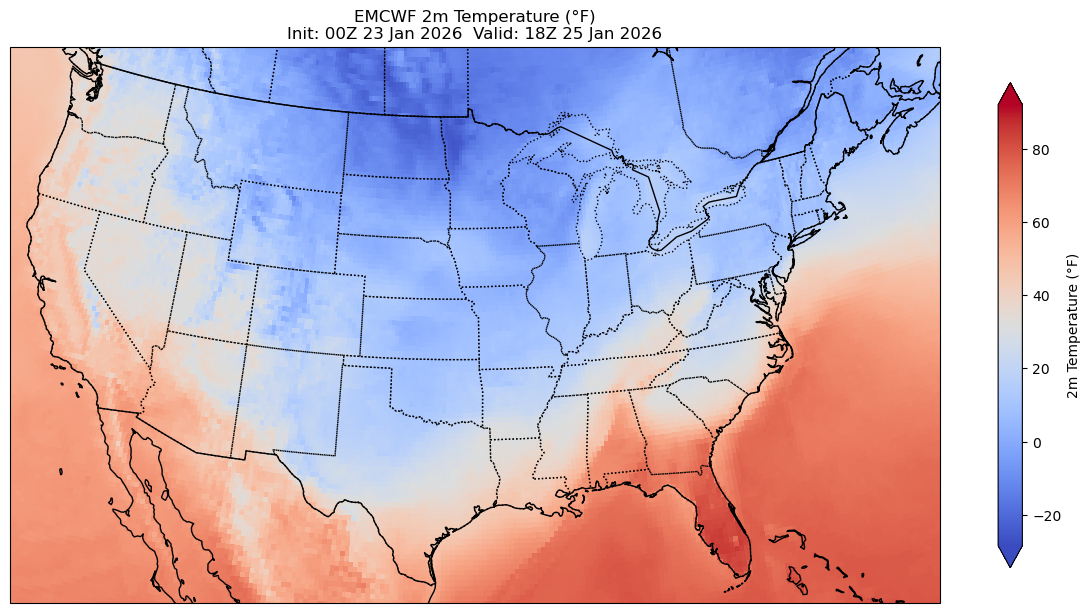

In [7]:
fig, ax = GeoAxes()

t2m = ds_test['t2m'].isel(valid_time=time_index)
cs = ax.pcolormesh(lon, lat, (t2m-273.15)*1.8+32, transform=dataproj, cmap='coolwarm')
plt.colorbar(cs, label = '2m Temperature (°F)', extend = 'both', shrink=0.7)
ax.set_title(f"EMCWF 2m Temperature (°F)\nInit: {init_str}  Valid: {valid_str}")

## 10m Wind Gust (PD)

Text(0.5, 1.0, 'EMCWF 10m Wind Gust (kt)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

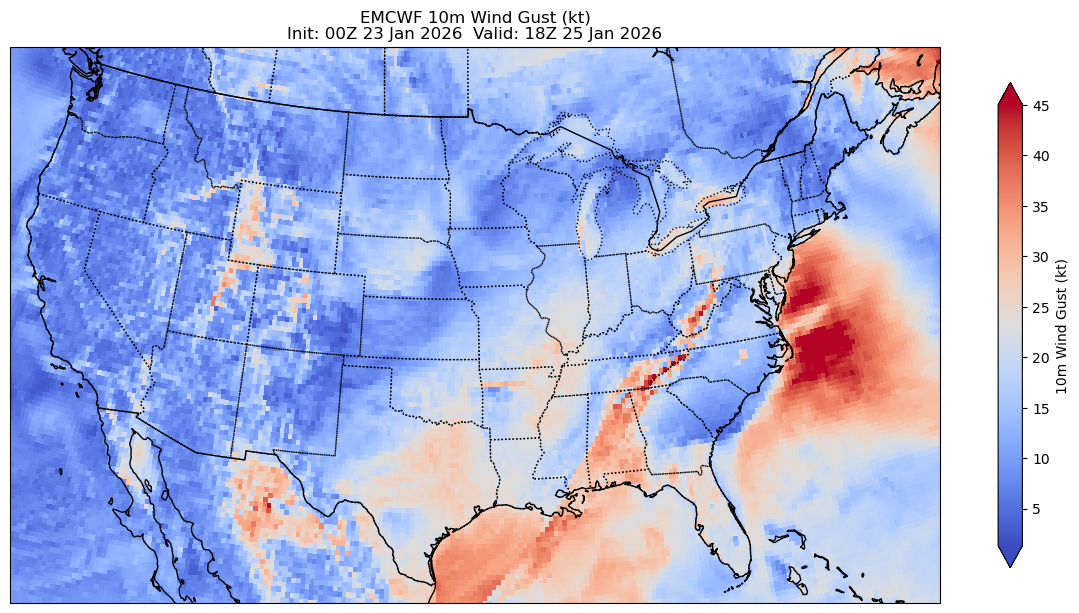

In [8]:
fig, ax = GeoAxes()
wgust = ds_test['fg10'].isel(valid_time=time_index)
cs = ax.pcolormesh(lon, lat, wgust*1.94384449, transform=dataproj, vmax=45, cmap='coolwarm')
plt.colorbar(cs, label = '10m Wind Gust (kt)', extend = 'both', shrink=0.7)
ax.set_title(f"EMCWF 10m Wind Gust (kt)\nInit: {init_str}  Valid: {valid_str}")

## Snow Depth (PD)

Text(0.5, 1.0, 'EMCWF Snow Depth (in)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

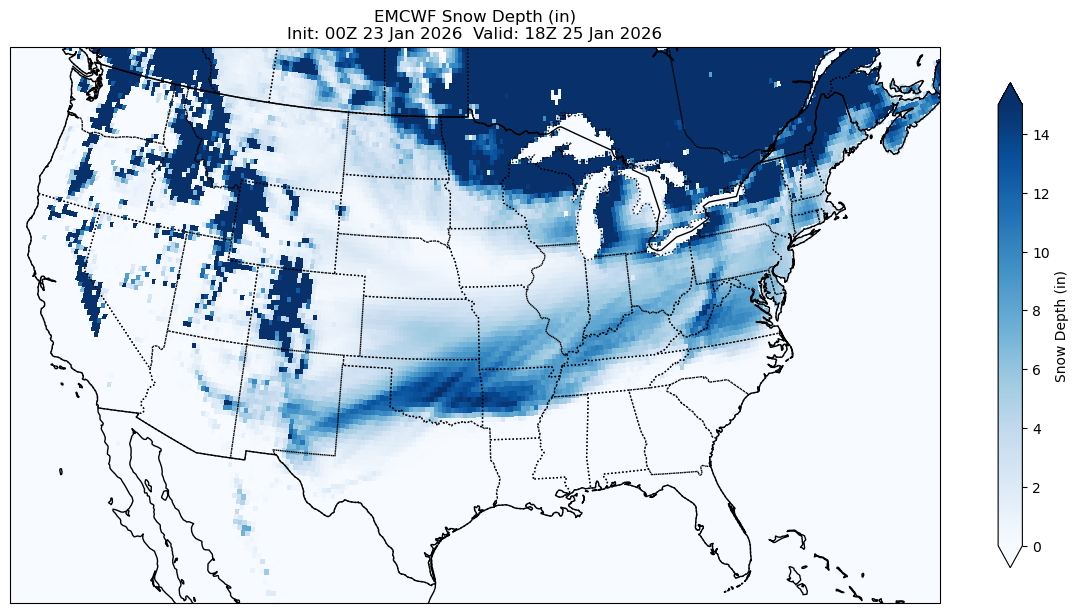

In [9]:
# Convert and plot snow depth in inches from the snow depth water equvialent variable in meters assuming a 10:1 snow to liquid ratio.
# There was no regular snowfall accumulation variable in the ECMWF database. 
fig, ax = GeoAxes()
snow_depth = ds_test['sd'].isel(valid_time=time_index)
cs = ax.pcolormesh(lon, lat, snow_depth*39.3700787*10, transform=dataproj, vmax=15, cmap='Blues')
plt.colorbar(cs, label = 'Snow Depth (in)', extend = 'both', shrink=0.7)
ax.set_title(f"EMCWF Snow Depth (in)\nInit: {init_str}  Valid: {valid_str}")

In [143]:
# Note: this may overestimate snow in areas that are forecast to see mixed precipitation which will lower snow-liquid ratios.
# This also includes previous high snow cover in the Rockies, Sierra Nevada, and Cascades mountain ranges, and Canada (the dark blue colors).

# Precipitation Type Plot (MP)
- Custom color map with different values being defined as different precipitation types

In [10]:
# custom color map (used ChatGPT to help with formatting and inputs for colors, values, and cmap)
ptype_colors = [
    "white",        # 0 = No precipitation
    "green",        # 1 = Rain
    "red",          # 3 = Freezing rain
    "blue",         # 5 = Snow
    "cyan",         # 6 = Wet snow
    "purple",       # 7 = Rain/Snow mix
    "orange",       # 8 = Ice pellets
    "pink"          # 12 = Freezing drizzle
]

ptype_values = [0, 1, 3, 5, 6, 7, 8, 12]

cmap = ListedColormap(ptype_colors)
norm = BoundaryNorm(ptype_values + [13], cmap.N)

Text(0.5, 1.0, 'EMCWF Precipitation Type \nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

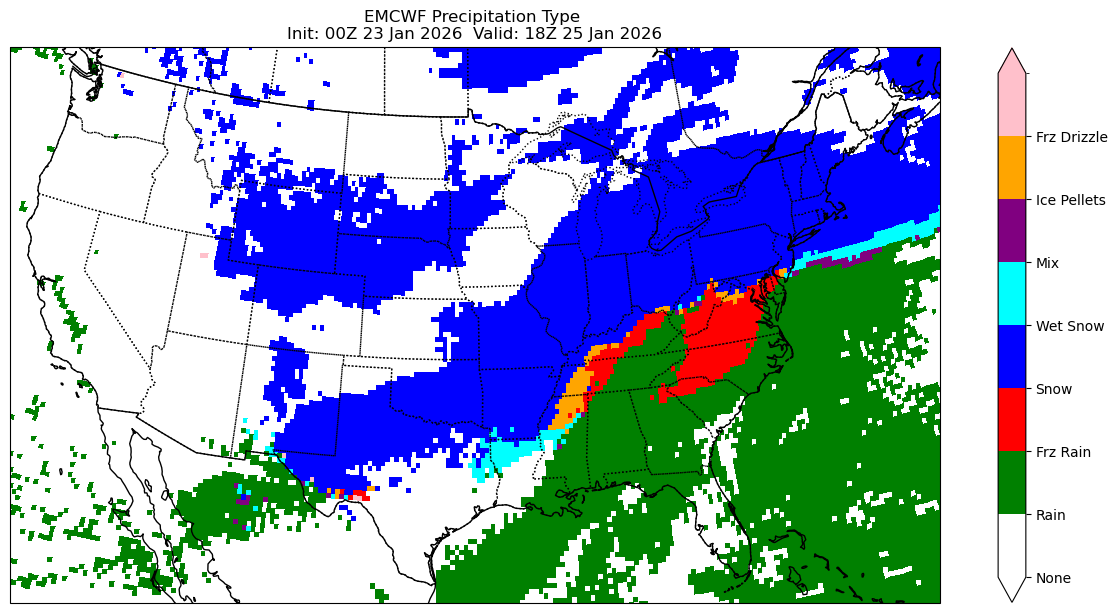

In [11]:
fig, ax = GeoAxes()

ptype = ds_test['ptype'].isel(valid_time=time_index)
mesh = ax.pcolormesh(
    lon, lat, ptype, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(mesh, ax=ax, extend = 'both', shrink=0.8)
cbar.set_ticks(ptype_values)
cbar.set_ticklabels([
    "None", "Rain", "Frz Rain", "Snow",
    "Wet Snow", "Mix", "Ice Pellets", "Frz Drizzle"])
ax.set_title(f"EMCWF Precipitation Type \nInit: {init_str}  Valid: {valid_str}")

# Derived Variable (Wind Chill) Plot (MP)
- using 1000 hPa wind speed

In [1]:
# deriving wind whill
u_wind = ds_test['u'].isel(isobaricInhPa=0).isel(valid_time=time_index)
v_wind = ds_test['v'].isel(isobaricInhPa=0).isel(valid_time=time_index)
# converting t2m to F
t2m_F = (t2m - 273.15) * 9/5 + 32
# calculating total wind
V_ms = np.sqrt(u_wind**2 + v_wind**2)
V_mph = V_ms * 2.237
# applying WC formula
wind_chill = (35.74 + 0.6215 * t2m_F - 35.75 * (V_mph ** 0.16) + 0.4275 * t2m_F * (V_mph ** 0.16))
# masking invalid conditions 
wind_chill = np.where((t2m_F <= 50) & (V_mph >= 3), wind_chill, np.nan)

NameError: name 'ds_test' is not defined

## Plot Wind Chill (MP)

In [19]:
# Define bounds, Used ChatGPT again for defining colors, bounds, values
bounds = [-30, -20, -10, 0, 10, 20, 30, 40, 50]

# colors
colors = ['purple', 'darkred', 'red', 'orange', 'yellow', 'yellowgreen', 'cyan', 'gray'] 
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

Text(0.5, 1.0, 'ECMWF Wind Chill (°F) \nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

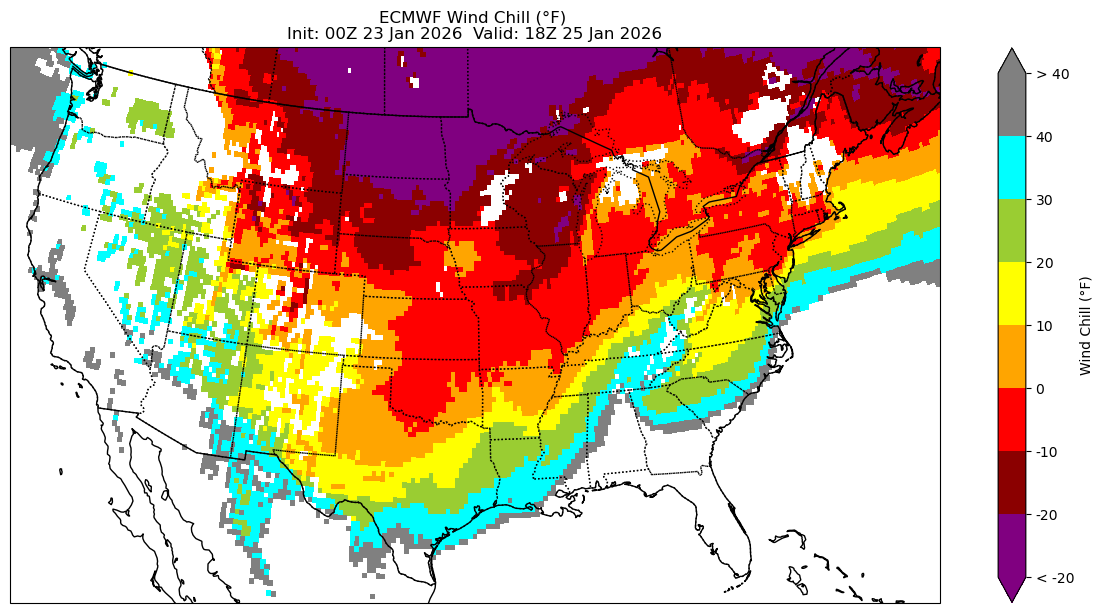

In [20]:
fig, ax = GeoAxes()

mesh = ax.pcolormesh(lon, lat, wind_chill, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

cbar = plt.colorbar(mesh, ax=ax, extend='both', shrink=0.8)
cbar.set_label("Wind Chill (°F)")
cbar.set_ticks(bounds)
cbar.set_ticklabels(["< -20", "-20", "-10", "0", "10", "20", "30", "40", "> 40"])
ax.set_title(f"ECMWF Wind Chill (°F) \nInit: {init_str}  Valid: {valid_str}")

## Precipitaton Rate Plot (MP)

In [21]:
# want to make custom color map for this as well
bounds = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 1.0, 2.0]

colors = ["white","blue","lightgreen","green","yellow", "orange","red",]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

Text(0.5, 1.0, 'EMCWF Total Precipitation Rate (In/hr)\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

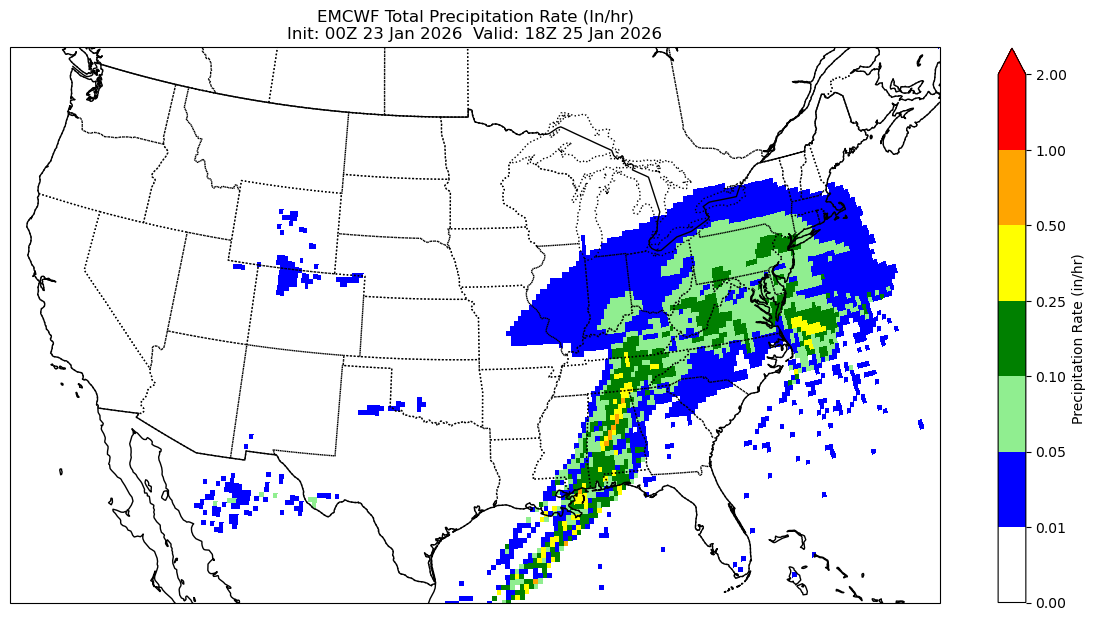

In [22]:
fig, ax = GeoAxes()

tprate = ds_test['tprate'].isel(valid_time=time_index)
cs = ax.pcolormesh(lon, lat, tprate*141.73, cmap=cmap, norm=norm, transform=dataproj)
cbar = plt.colorbar(cs, ax=ax, extend='max', shrink = 0.8)
cbar.set_label("Precipitation Rate (in/hr)")
ax.set_title(f"EMCWF Total Precipitation Rate (In/hr)\nInit: {init_str}  Valid: {valid_str}")

# Part 4 - Basic Index Design (MP and PD)
- We are thinking of making the output range 0-5 with 0 being no hazard and 5 being the greatest hazard. This is an easily digestable range for the general public, and can be interpreted well.
- Temperatures below freezing can be weighted higher due to chances of ice, snow, and mixed precipitation
- Precipitation rate may be weighted highest because high rates can cause quick accumulation of ice and snow
- Low wind chill values can be dangerous to the public with extreme values causing possible frostbite
- Precipitaton type can have a large impact to road and travel conditions with snow and ice accumulations making it difficult to drive
- 10m wind gusts can cause low visibility by blowing already fallen snow
- Snow depth may not be weighted as much as other variables over those such as precipitation rate, wind chill, and wind gusts because these are showing what is happening currently
- Visibility is also a condition that we may want to consider in later parts of this project, but it was not available in our dataset